# Prepare and export stream files with `f3ast`

This notebook aims to give an overview of possible functionalities of the `f3ast` package, with probably only parts of it relevant to your specific structure/problem. Mix and match to your heart's delight :-)


## Import packages and define microscope settings


In [1]:
import f3ast
import numpy as np

In [2]:
# or settings can be defined manually in a dictionary:
settings = {}
settings["structure"] = {"pitch": 2, "fill": False}  # in nm
settings["stream_builder"] = {
    "addressable_pixels": [65536, 56576],
    "max_dwt": 5,  # in ms
    "cutoff_time": 0.01,  # in ms, for faster exporting: remove dwells below cutoff time
    "screen_width": 10.2e3,  # in nm, horizontal screen width / field of view
    # 'serpentine' or 'serial', scanning order between slices
    "scanning_order": "serpentine",
}
# pixel size for thermal resistance
settings["dd_model"] = {"single_pixel_width": 50}

## Import and modify `stl` structure


In [3]:
file_path = "CylindersWithSphere-HiRemeshRes.stl"
struct = f3ast.Structure.from_file(file_path, **settings["structure"])

# rotate: specify axis and angle in degrees
rotation_axis, rotation_angle = (1, 0, 0), 0
struct.rotate(rotation_axis, rotation_angle)

# struct.mirror(normal=(1, 0, 0))
struct.centre()  # centers xy to zero and sets minimum z value to zero
struct.rescale(300)  # scale the structure

# interactive plot for inspection
struct.show()

## Define the growth model

For the two main growth models - RRL (reaction-rate limited growth) with constant dwell time in height, and DD (desorption-dominated growth), for which the dwell time are modified taking into account increasing thermal resistance with structure length and height.


In [4]:
GR0 = 0.29 # in um/s, base growth rate
k = 1.2 # in 1/nm?, thermal conductivity 
sigma = 4.0 # in nm, dwell size

# with correction due to thermal conductivity
%time model = f3ast.DDModel(struct, GR0, k, sigma, **settings['dd_model'])

Slicing...
Sliced
CPU times: total: 26.8 s
Wall time: 10.4 s


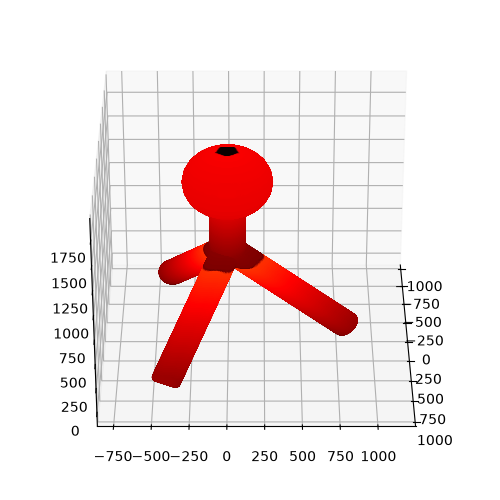

In [5]:
# plot thermal resistance for a check
ax, sc = struct.plot_slices(c=np.concatenate(model.resistance), cmap="hot")
ax.view_init(azim=0)

## Solve for dwells and inspect


Solving for dwells...
Solved
CPU times: total: 2.45 s
Wall time: 1min 55s


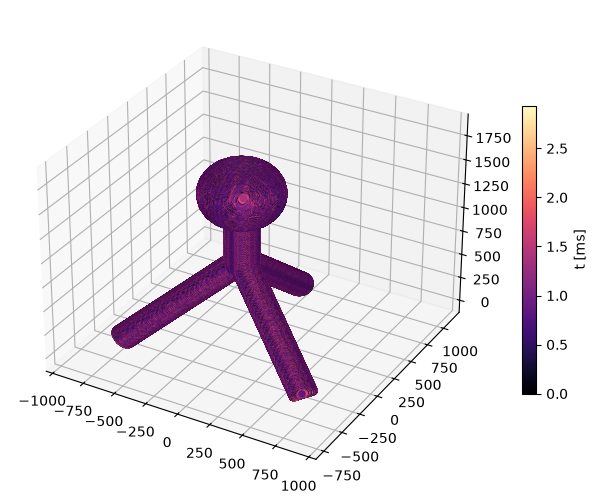

In [8]:
%time stream_builder, dwell_solver = f3ast.StreamBuilder.from_model(model, **settings['stream_builder'])
# dwell_solver.print_total_time()

# inspect dwells 
ax, sc = dwell_solver.show_solution()

## Export stream files

Depending on the interface of the SEM/dual beam you are working with, the visible name of the stream file might be very short (e.g., 18 characters only for the Helios 600). In this case, it makes sense to keep a short filename, and/or put the most important pieces of information of the pattern into the beginning.

It can be helpful to also add the total writing time for an exported stream at the end, see example below how to create a descriptive filename from patterning parameters.


In [37]:
# get stream
strm = stream_builder.get_stream()

# export with simple name
out_filename = "WSphereHiRemesh300x"

# this is an example on how to build a descriptive filename
# e.g. with growth rate GR0 in nm/s, and total writing time in seconds
total_time = f"{strm.get_time().seconds}.{strm.get_time().microseconds/1e5:.0f}s"
out_filename = f"{out_filename}-GR{GR0*1e3:.0f}-{total_time}"
strm.write(f"{out_filename}.str")
